<a href="https://www.kaggle.com/code/alexvmt/train-and-evaluate-terainet?scriptVersionId=247195700" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Train and evaluate TeraiNet

1. Set variables and parameters
2. Prepare train, val and test datasets
3. Prepare model
4. Train model
5. Evaluate model
6. Log run to W&B

## Setup

### Change working directory

In [1]:
%cd ../../

/


### Clone TeraiNet repo

**TODO: CLONE REPO FROM MAIN BRANCH**

In [2]:
!git clone -b feat/improve-modeling https://github.com/alexvmt/terainet.git

Cloning into 'terainet'...
remote: Enumerating objects: 479, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (136/136), done.
remote: Total 479 (delta 81), reused 52 (delta 27), pack-reused 316 (from 1)
Receiving objects: 100% (479/479), 9.94 MiB | 22.02 MiB/s, done.
Resolving deltas: 100% (250/250), done.


### Imports

Follow [mewc-flow](https://github.com/zaandahl/mewc-flow/blob/main/requirements.txt) for the key package versions

In [3]:
!pip install keras==3.3.3 kimm==0.2.5 tensorflow==2.16.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 3.8 MB/s eta 0:00:00


In [4]:
import os
import sys
import time
import yaml
import shutil
import random
import numpy as np
import pandas as pd

import kimm
import keras
import tensorflow as tf
import tensorflow_datasets as tfds
from keras import layers, optimizers, losses, callbacks, saving
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import wandb
from kaggle_secrets import UserSecretsClient

In [5]:
# add folder to sys.path so that utilities can be imported
project_dir = 'terainet'
sys.path.append(project_dir)

In [6]:
from utilities import load_config, create_class_list_yaml_file, sample_images

### Set variables and parameters

In [7]:
# load config
config_path = os.path.join(project_dir, 'config.yaml')
config = load_config(config_path)

# set num classes and class names
num_classes = config['classes']['num_classes']
class_names = [key for key in config['classes'] if key != 'num_classes']

# set seed
seed = 42

# set n train, val and test images
n_train_images = 2000
n_val_images = 250
n_test_images = 250

# define paths to train, val and test images
images_input_dir = config['training']['images_input_dir']
images_sampled_dir = config['training']['images_sampled_dir']
!mkdir -p "$images_sampled_dir"
train_dir = os.path.join(images_input_dir, config['training']['train_dir'])
train_sampled_dir = os.path.join(images_sampled_dir, config['training']['train_sampled_dir'])
val_dir = os.path.join(images_input_dir, config['training']['val_dir'])
val_sampled_dir = os.path.join(images_sampled_dir, config['training']['val_sampled_dir'])
test_dir = os.path.join(images_input_dir, config['training']['test_dir'])
test_sampled_dir = os.path.join(images_sampled_dir, config['training']['test_sampled_dir'])
test2_dir = os.path.join(images_input_dir, config['training']['test2_dir'])

# model
model_constructor = 'EfficientNetV2S'
model_path = config['training']['model_path']
classification_report_path = config['training']['classification_report_path']
confusion_matrix_path = config['training']['confusion_matrix_path']

# set image size
img_size = 224

# set batch size
batch_size = 8

# augmentations
apply_augmentations = False

# decide whether to log run or not
wb_project = config['training']['wb_project']
logging = True

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: Using fork() can cause Polars to deadlock in the child process.
In addition, using fork() with Python in general is a recipe for mysterious
deadlocks and crashes.

The most likely reason you are seeing this error is because you are using the
multiprocessing module on Linux, which uses fork() by default. This will be
fixed in Python 3.14. Until then, you want to use the "spawn" context instead.

See https://docs.pola.rs/user-guide/misc/multiprocessing/ for details.

  pid, fd = os.forkpty()
/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [8]:
# create class list yaml file which is needed later for deployment
class_list_yaml_path = config['training']['class_list_yaml_path']
create_class_list_yaml_file(num_classes, class_names, class_list_yaml_path)

In [9]:
# log in to w&b using api key
if logging:
    user_secrets = UserSecretsClient()
    key = user_secrets.get_secret('wandb')
    !wandb login $key

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


## Prepare train, val and test datasets

### Sample images

In [10]:
# create new directory with sampled train images
sample_images(train_dir, train_sampled_dir, n_train_images)

In [11]:
# create new directory with sampled val images
sample_images(val_dir, val_sampled_dir, n_val_images)

In [12]:
# TODO: Move this to sampling/downloading

# Quick fix!
# The images from the Amur tiger re-identification challenge
# come already split into train and test.
# We therefore need to sample a separate val set
# from the existing train set ourselves.
# Ideally this should be done on raw images that haven't yet
# been processed by MegaDetector and subsequently cropped.
# For now, this is done on cropped images here, ensuring that
# the sampled val images don't stem from the same raw images
# as those images sampled for train.

# create target dir
class_dir = 'class_1'
target_dir = os.path.join(val_sampled_dir, class_dir)
os.makedirs(target_dir, exist_ok=True)

# get excluded prefixes
exclude_dir = os.path.join(train_sampled_dir, class_dir)
exclude_prefixes = {
    f.split('-')[0]
    for f in os.listdir(exclude_dir)
    if os.path.isfile(os.path.join(exclude_dir, f))
}

# get eligible files
source_dir = os.path.join(train_dir, class_dir)
eligible_files = [
    f for f in os.listdir(source_dir)
    if f.split('-')[0] not in exclude_prefixes
]

# reproducible sampling
random.seed(seed)
sampled_files = random.sample(eligible_files, n_val_images)

# copy files
for f in sampled_files:
    shutil.copy2(os.path.join(source_dir, f), os.path.join(target_dir, f))

In [13]:
# create new directory with sampled test images
sample_images(test_dir, test_sampled_dir, n_test_images)

### Create datasets

In [14]:
# create train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_sampled_dir,
    label_mode='categorical',
    shuffle=True,
    seed=seed,
)

# create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_sampled_dir,
    label_mode='categorical',
    shuffle=False,
)

# create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_sampled_dir,
    label_mode='categorical',
    shuffle=False,
)

# create test2 dataset
test2_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test2_dir,
    label_mode='categorical',
    shuffle=False,
)

# we need to unbatch because there's somehow an unwanted additional dimension
train_ds = train_ds.unbatch()
val_ds = val_ds.unbatch()
test_ds = test_ds.unbatch()
test2_ds = test2_ds.unbatch()

print(f'Number of train samples: {train_ds.cardinality()}')
print(f'Number of val samples: {val_ds.cardinality()}')
print(f'Number of test samples: {test_ds.cardinality()}')

Found 19941 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.
Found 296 files belonging to 1 classes.
Number of train samples: -2
Number of val samples: -2
Number of test samples: -2


In [15]:
# check dimensions
print(train_ds.element_spec, val_ds.element_spec, test_ds.element_spec)

(TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None)) (TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None)) (TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(10,), dtype=tf.float32, name=None))


### Resize (and augment) images

In [16]:
# resize images and setup datasets with tf.data
resize_fn = keras.layers.Resizing(img_size, img_size)

# define augmentations
data_augmentations = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.05),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomContrast(0.1),
    keras.layers.Lambda(lambda x: tf.image.random_brightness(x, max_delta=0.1)),
    keras.layers.Lambda(lambda x: tf.image.random_saturation(x, lower=0.9, upper=1.1)),
    keras.layers.Lambda(lambda x: tf.image.random_hue(x, max_delta=0.02)),
])

# apply resizing + augmentations to training data
if apply_augmentations:
    train_ds = train_ds.map(lambda x, y: (data_augmentations(resize_fn(x), training=True), y))
else:
    train_ds = train_ds.map(lambda x, y: (resize_fn(x), y))

# only resize validation and test data
val_ds = val_ds.map(lambda x, y: (resize_fn(x), y))
test_ds = test_ds.map(lambda x, y: (resize_fn(x), y))
test2_ds = test2_ds.map(lambda x, y: (resize_fn(x), y))

train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()
test2_ds = test2_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE).cache()

## Prepare model

In [17]:
# create base model
# TODO: make image size flexible
if model_constructor == 'EfficientNetV2B0':
    base_model = kimm.models.EfficientNetV2B0(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '5M'
    frozen_file_size = '26MB'
elif model_constructor == 'EfficientNetV2B2':
    base_model = kimm.models.EfficientNetV2B2(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '9M'
    frozen_file_size = '37MB'
elif model_constructor == 'EfficientNetV2S':
    base_model = kimm.models.EfficientNetV2S(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '21M'
    frozen_file_size = '84MB'
elif model_constructor == 'EfficientNetV2M':
    base_model = kimm.models.EfficientNetV2M(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '54M'
    frozen_file_size = '216MB'
elif model_constructor == 'EfficientNetV2L':
    base_model = kimm.models.EfficientNetV2L(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '119M'
    frozen_file_size = '475MB'
elif model_constructor == 'EfficientNetV2XL':
    base_model = kimm.models.EfficientNetV2XL(
        input_shape=(224, 224, 3),
        include_preprocessing=True,
        include_top=False,
    )
    model_params = '208M'
    frozen_file_size = '835MB'
else:
    raise Exception('Please select a valid model constructor.') 

# freeze base model
base_model.trainable = False

# create new model on top
inputs = keras.Input(shape=(img_size, img_size, 3))
x = inputs

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)  # regularize with dropout
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable=True)

87666342/87666342 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ EfficientNetV2S             │ (None, 7, 7, 1280)    │ 20,331,360 │   N   │
│ (EfficientNetV2S)           │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 10)            │     12,810 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,344,170 (77.61 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

## Train model

Follow [mewc-train](https://github.com/zaandahl/mewc-train) for the training parameters

In [18]:
df_size = int(n_train_images * num_classes)
epochs = 50
lr_init = 1e-4
min_lr_frac = 1/5 # default minimum learning rate fraction of initial learning rate
steps_per_epoch = df_size // batch_size
total_steps = epochs * steps_per_epoch # total number of steps for monotonic exponential decay across all epochs
lr = optimizers.schedules.ExponentialDecay(initial_learning_rate=lr_init, decay_steps=total_steps, decay_rate=min_lr_frac, staircase=False)
amsgrad = True
weight_decay = 1e-4
optimizer = optimizers.AdamW(learning_rate=lr, amsgrad=amsgrad, weight_decay=weight_decay)

# ensure that loss can be calculated across gpus
if num_classes == 2:
  loss_f = losses.BinaryFocalCrossentropy()  # use for binary classification tasks
  act_f = 'sigmoid' # use for binary classification tasks
else:
  loss_f = losses.CategoricalFocalCrossentropy()  # use for unbalanced multi-class tasks (typical for wildlife datasets)
  act_f = 'softmax' # use for multi-class classification tasks

metrics = ['accuracy']

callbacks = [callbacks.EarlyStopping(monitor='loss', mode='min', min_delta=0.001, patience=5, restore_best_weights=True)]

In [19]:
# compile model
model.compile(
    optimizer=optimizer,
    loss=loss_f,
    metrics=metrics,
)

In [20]:
# train model
start_time = time.time()
history = model.fit(train_ds, epochs=epochs, callbacks=callbacks, validation_data=val_ds)
end_time = time.time()
training_time_mins = round((end_time - start_time) / 60, 2)
print(f'Training time mins: {training_time_mins}')

Epoch 1/50


I0000 00:00:1750795417.860538     110 service.cc:145] XLA service 0x7a44ec004920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750795417.860607     110 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


      5/Unknown 24s 28ms/step - accuracy: 0.1304 - loss: 0.5766

I0000 00:00:1750795427.051439     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   2493/Unknown 104s 32ms/step - accuracy: 0.5587 - loss: 0.2563

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


2493/2493 ━━━━━━━━━━━━━━━━━━━━ 123s 40ms/step - accuracy: 0.5587 - loss: 0.2563 - val_accuracy: 0.8416 - val_loss: 0.0766
Epoch 2/50
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 60s 24ms/step - accuracy: 0.8359 - loss: 0.0802 - val_accuracy: 0.8676 - val_loss: 0.0618
Epoch 3/50
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 59s 24ms/step - accuracy: 0.8593 - loss: 0.0663 - val_accuracy: 0.8812 - val_loss: 0.0558
Epoch 4/50
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 60s 24ms/step - accuracy: 0.8731 - loss: 0.0573 - val_accuracy: 0.8844 - val_loss: 0.0529
Epoch 5/50
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 59s 24ms/step - accuracy: 0.8756 - loss: 0.0526 - val_accuracy: 0.8876 - val_loss: 0.0508
Epoch 6/50
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 59s 24ms/step - accuracy: 0.8869 - loss: 0.0485 - val_accuracy: 0.8896 - val_loss: 0.0497
Epoch 7/50
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 59s 24ms/step - accuracy: 0.8929 - loss: 0.0459 - val_accuracy: 0.8940 - val_loss: 0.0485
Epoch 8/50
2493/2493 ━━━━━━━━━━━━━━━━━━━━ 59s 24ms/step - accuracy: 0.8972 - loss: 0.0

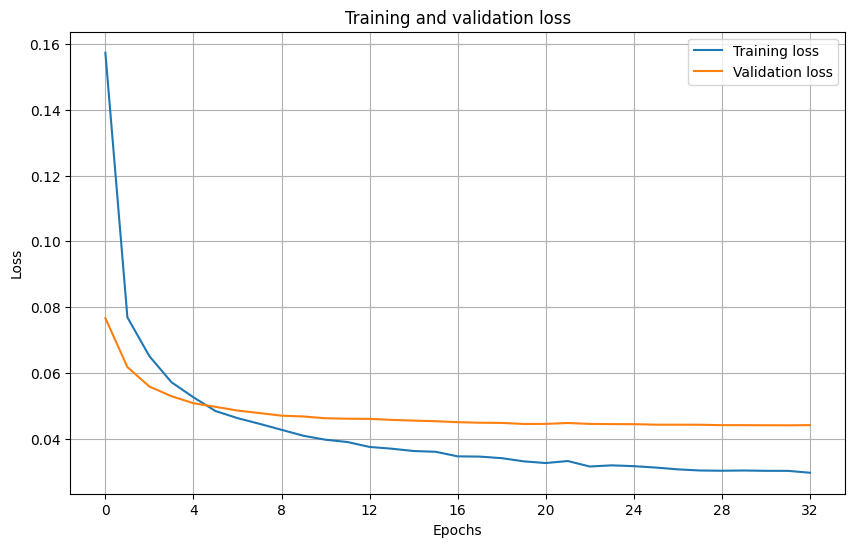

In [21]:
# visualize train and val loss
train_loss = history.history['loss']
val_loss = history.history.get('val_loss')

plt.figure(figsize=(10,6))
plt.plot(train_loss, label='Training loss')
plt.plot(val_loss, label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid()
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.show()

In [22]:
saving.save_model(model, model_path, include_optimizer=False)

## Evaluate model

### Get predictions on test dataset

In [23]:
test_accuracy = model.evaluate(test_ds)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9094 - loss: 0.0432


In [24]:
test2_accuracy = model.evaluate(test2_ds)

37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8404 - loss: 9.8073


In [25]:
true_labels = []
predicted_labels = []

for images, labels in test_ds:
    # append true labels based on their format
    if len(labels.shape) > 1:  # if one-hot encoded
        true_labels.append(np.argmax(labels.numpy(), axis=1))
    else:  # if integer labels
        true_labels.append(labels.numpy())

    # predict labels
    predictions = model.predict(images)
    predicted_labels.append(np.argmax(predictions, axis=1))

# combine all batches into single arrays
true_labels = np.concatenate(true_labels)
predicted_labels = np.concatenate(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━

### Get performance metrics, classification report and confusion matrix

In [26]:
precision = precision_score(true_labels, predicted_labels, average='macro')
recall = recall_score(true_labels, predicted_labels, average='macro')
f1 = f1_score(true_labels, predicted_labels, average='macro')
print(f'Test accuracy: {test_accuracy[1]:.4f}\nTest2 accuracy: {test2_accuracy[1]:.4f}\nTest precision: {precision:.4f}\nTest recall: {recall:.4f}\nTest f1-score: {f1:.4f}')

Test accuracy: 0.8772
Test2 accuracy: 0.8412
Test precision: 0.8788
Test recall: 0.8772
Test f1-score: 0.8768


In [27]:
cr_dict = classification_report(true_labels, predicted_labels, target_names=class_names, output_dict=True)

# remove scalar 'accuracy'
cr_dict.pop('accuracy', None)

# add micro avg manually
micro_avg = {
    'precision': precision_score(true_labels, predicted_labels, average='micro'),
    'recall': recall_score(true_labels, predicted_labels, average='micro'),
    'f1-score': f1_score(true_labels, predicted_labels, average='micro'),
    'support': len(true_labels)
}
cr_dict['micro avg'] = micro_avg

# reorder: class entries + micro avg + macro avg + weighted avg
ordered_keys = (
    class_names + 
    ['micro avg', 'macro avg', 'weighted avg']
)

# rebuild dict with correct order
ordered_cr_dict = {k: cr_dict[k] for k in ordered_keys if k in cr_dict}

cr_df = pd.DataFrame(ordered_cr_dict).transpose()
cr_df.to_csv(classification_report_path)
print('Classification report:\n', cr_df)

Classification report:
                   precision  recall  f1-score  support
tiger              0.996000  0.9960  0.996000    250.0
leopard            0.881356  0.8320  0.855967    250.0
black_bear         0.954545  0.9240  0.939024    250.0
other_carnivores   0.877637  0.8320  0.854209    250.0
deer               0.820312  0.8400  0.830040    250.0
wild_boar          0.914062  0.9360  0.924901    250.0
buffalo            0.885185  0.9560  0.919231    250.0
rhino              0.844262  0.8240  0.834008    250.0
elephant           0.848624  0.7400  0.790598    250.0
bird               0.766323  0.8920  0.824399    250.0
micro avg          0.877200  0.8772  0.877200   2500.0
macro avg          0.878831  0.8772  0.876838   2500.0
weighted avg       0.878831  0.8772  0.876838   2500.0


In [28]:
cm = confusion_matrix(true_labels, predicted_labels)
print('Confusion matrix:\n', cm)

Confusion matrix:
 [[249   0   0   0   0   0   0   0   0   1]
 [  0 208   0   3   1   5   2  18   4   9]
 [  1   3 231   2   8   1   0   0   3   1]
 [  0   3   4 208  22   1  10   1   0   1]
 [  0   6   5   7 210  10   6   4   0   2]
 [  0   0   0   3   6 234   4   0   2   1]
 [  0   0   0   7   2   0 239   2   0   0]
 [  0   6   1   3   3   5   8 206  10   8]
 [  0   7   1   1   2   0   1   8 185  45]
 [  0   3   0   3   2   0   0   5  14 223]]


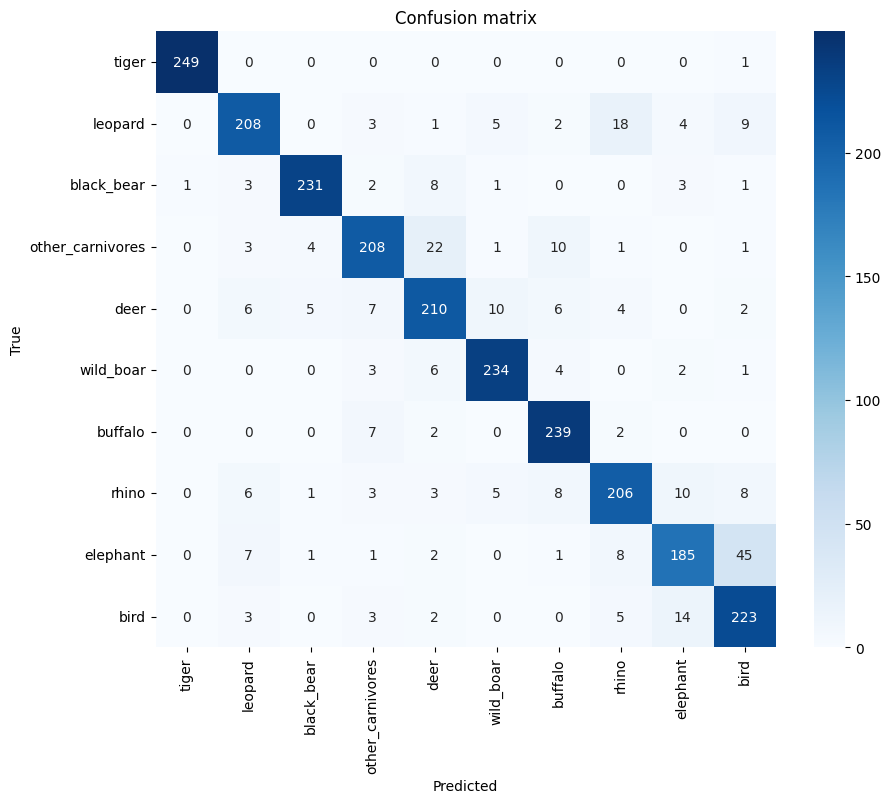

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
plt.show()

## Log run to W&B

In [30]:
if logging:
    run = wandb.init(
        project=wb_project,
        config={
            'model_constructor': model_constructor,
            'model_params': model_params,
            'frozen_file_size': frozen_file_size,
            'img_size': img_size,
            'num_classes': num_classes,
            'n_train_images': n_train_images,
            'n_val_images': n_val_images,
            'n_test_images': n_test_images,
            'augmentations': str(apply_augmentations),
            'batch_size': batch_size,
            'epochs': epochs,
        },
    )
    wandb.log({
        'training_time_mins': training_time_mins,
        'test_accuracy': round(test_accuracy[1], 4),
        'test2_accuracy': round(test2_accuracy[1], 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
    })
    artifact = wandb.Artifact('classification_results', type='evaluation')
    artifact.add_file(classification_report_path)
    artifact.add_file(confusion_matrix_path)
    wandb.log_artifact(artifact)
    wandb.finish()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: alexvmt. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.18.7
wandb: Run data is saved locally in /wandb/run-20250624_203906-id8chah4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run jumping-cherry-21
wandb: ⭐️ View project at https://wandb.ai/alexvmt/TeraiNet
wandb: 🚀 View run at https://wandb.ai/alexvmt/TeraiNet/runs/id8chah4
wandb:                                                                                
wandb: 
wandb: Run history:
wandb:                 f1 ▁
wandb:          precision ▁
wandb:             recall ▁
wandb:     test2_accuracy ▁
wandb:      test_accuracy ▁
wandb: training_time_mins ▁
wandb: 
wandb: Run summary:
wandb:                 f1 0.8768
wandb:          precision 0.8788
wandb:             recall 0.8772
wandb:     test2_accuracy 0.8412
wandb:      test_accuracy 0.8